# BBM409 Assignment_4

Name : Mustafa Yüksekkaya

ID   : 2240356165

☺

Name : Semih Kara

ID   : 2230356076

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import cv2
import os
import glob
import random

bunları senin için yazıyorum görüp okuduktan sonra sil __ayrıca bütün blokları çalıştır deme__

ayrıca kullanmaya başlamadan önce gerekli kütüphaneleri indirdiğine emin ol temel olanlar zaten vardır diyorum ek olarak

``pip install mediapipe tslearn``

## Part 1: Feature Extraction

In [9]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = 'face_landmarker.task'

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=mp.tasks.vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
detector = FaceLandmarker.create_from_options(options)

işleyecek fonksiyonlar bunlar

mediapipe şeyi yüzü tanıyıp üzerinde 500 civarında nokta belirliyor biz de bu noktaları kullanarak hareketlerine göre model eğitecez

In [10]:
LIP_INDICES = [
    61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 185, 40, 39, 37, 0, 267, 269, 270, 409,
    78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308, 191, 80, 81, 82, 13, 312, 311, 310, 415
]
JAW_INDICES = [
    152, 377, 400, 378, 379, 365, 397, 288, 361, 323,
    148, 176, 149, 150, 136, 172, 58, 132, 93,
]
CHEEK_INDICES = [
    205, 207, 214, 212, 192, 211, 170, 140,
    425, 427, 434, 432, 416, 431, 395, 369
]

MOUTH_INDICES = LIP_INDICES + JAW_INDICES + CHEEK_INDICES

def parse_align_file(align_path):
    words = []
    with open(align_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                start_val, end_val, label = parts
                if label == 'sil':
                    continue
                
                start_frame = int(start_val) // 1000
                end_frame = int(end_val) // 1000
                
                words.append((start_frame, end_frame, label))
    return words

def extract_lip_landmarks(video_path):
    cap = cv2.VideoCapture(video_path)
    frames_landmarks = []
    
    last_known_landmarks = np.zeros((len(MOUTH_INDICES), 2)) 

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        
        detection_result = detector.detect(mp_image)
        
        frame_landmarks = []
        if detection_result.face_landmarks:
            face_landmarks = detection_result.face_landmarks[0]
            for idx in MOUTH_INDICES:
                landmark = face_landmarks[idx]
                frame_landmarks.append([landmark.x, landmark.y])
            
            last_known_landmarks = np.array(frame_landmarks)
            frames_landmarks.append(last_known_landmarks)
        else:
            frames_landmarks.append(last_known_landmarks)
            
    cap.release()
    return np.array(frames_landmarks)

def process_dataset(video_base_dir, align_base_dir, output_dir, test_size):
    train_dir = os.path.join(output_dir, 'train')
    test_dir = os.path.join(output_dir, 'test')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
        
    video_folders = glob.glob(os.path.join(video_base_dir, '*'))
    
    for folder in video_folders:
        speaker_id = os.path.basename(folder)
        video_files = glob.glob(os.path.join(folder, '*.mpg'))
        
        random.shuffle(video_files)
        split_index = int(len(video_files) * (1 - test_size))
        
        train_videos = video_files[:split_index]
        test_videos = video_files[split_index:]
        
        def process_video_list(video_list, target_dir):
            for video_path in video_list:
                video_filename = os.path.basename(video_path)
                base_name = os.path.splitext(video_filename)[0]
                align_path = os.path.join(align_base_dir, speaker_id, f"{base_name}.align")
                
                if not os.path.exists(align_path):
                    continue
                    
                words_info = parse_align_file(align_path)
                all_landmarks = extract_lip_landmarks(video_path)
                total_frames = len(all_landmarks)
                
                for idx, (start_frame, end_frame, label) in enumerate(words_info):
                    start_frame = max(0, start_frame)
                    end_frame = min(total_frames, end_frame)
                    word_sequence = all_landmarks[start_frame:end_frame]
                    
                    if len(word_sequence) == 0:
                        continue
                        
                    out_filename = f"{label}_{speaker_id}_{base_name}_{idx}.npz"
                    out_filepath = os.path.join(target_dir, out_filename)
                    np.savez_compressed(
                        out_filepath, 
                        landmarks=word_sequence, 
                        label=label,
                        original_video=video_path
                    )
        
        process_video_list(train_videos, train_dir)
        process_video_list(test_videos, test_dir)
    print("Finished")

bu veriyi işliyor ve npz olarak kaydediyor çalışması uzun sürüyor o yüzden uğraşma diye atmışımdır bunun outputunu githuba

In [13]:
video = "data"
align = "data/alignments"
output = "features"

process_dataset(video, align, output, test_size=0.2)

Finished


burası da işlediğimiz kısmı okuyup kullanmaya hazır hale getiriyor sen importları ve burayı çalıştırıp kullanmaya başlayabilirsin

In [2]:
total = []
def normalize_sequence(sequence):
    mean = np.mean(sequence, axis=(0, 1), keepdims=True)
    centered = sequence - mean
    
    std = np.std(centered, axis=(0, 1), keepdims=True)
    normalized = centered / (std + 1e-8)
    
    return normalized

def pad_or_truncate(sequence, max_seq_length):
    num_frames, num_landmarks, num_coords = sequence.shape
    total.append(num_frames)
    if num_frames > max_seq_length:
        return sequence[:max_seq_length]
    elif num_frames < max_seq_length:
        pad_length = max_seq_length - num_frames
        pad_array = np.zeros((pad_length, num_landmarks, num_coords))
        return np.vstack((sequence, pad_array))
    else:
        return sequence

def load_and_prepare_data(data_dir, max_seq_length=30):
    npz_files = glob.glob(os.path.join(data_dir, "*.npz"))
    
    X = []
    y = []
    
    for file_path in npz_files:
        data = np.load(file_path)
        landmarks = data['landmarks']
        label = str(data['label'])
        
        norm_landmarks = normalize_sequence(landmarks)
        fixed_landmarks = pad_or_truncate(norm_landmarks, max_seq_length)
        
        num_frames = fixed_landmarks.shape[0]
        flattened_features = fixed_landmarks.reshape(num_frames, -1)
        
        X.append(flattened_features)
        y.append(label)
        
    return np.array(X), np.array(y)

In [3]:
from sklearn.preprocessing import LabelEncoder

train_dir = "features/train"
test_dir = "features/test"

# Max:21, Min:1, Avg:6.13
MAX_SEQ_LENGTH = 10

X_train, y_train_str = load_and_prepare_data(train_dir, MAX_SEQ_LENGTH)
X_test, y_test_str = load_and_prepare_data(test_dir, MAX_SEQ_LENGTH)

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train_str)

y_test = label_encoder.transform(y_test_str)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Number of classes: {len(label_encoder.classes_)}")

X_train shape: (4812, 10, 150)
y_train shape: (4812,)
X_test shape:  (1202, 10, 150)
Number of classes: 52


## Part 2: Model Selection

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix
from tslearn.svm import TimeSeriesSVC

In [15]:
def train_evaluate_gak_svm(X_train, y_train, X_test, y_test, label_encoder, C=1.0, gamma="auto"):
    
    model = TimeSeriesSVC(kernel="gak", C=C, gamma=gamma, probability=True)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"C: {C:4.1f} | gamma: {gamma:4} | Accuracy: {accuracy*100:8.4f}%")
    
    cm = confusion_matrix(y_test, y_pred)
    
    target_names = label_encoder.classes_
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues', 
                xticklabels=target_names, 
                yticklabels=target_names)
    plt.title("GAK + SVM Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()
    
    results = {
        'model_name': 'GAK + SVM',
        'accuracy': accuracy,
        'y_pred': y_pred,
        'model': model
    }
    
    return results

üstteki fonksiyon da svm eğitiyor analizlerini yazdırıp çiziyor sonuçları da dönüyor

istersen çizdirme kısmını silip loop içinde parametre analizi yapabilirsin falan takıl kafana göre

bundan sonra diğer iki modeli de hazırla son bizim seçeceğimiz için de yapabilirsen ben cnn yap derim onda bir de veriyi lineer yapmak zorunda değiliz ona göre de ayarlayarak yaparsak baya iyi sonuç çıkar bence bu bile yeterince iyiyken o uçar devamında analiz kısmını da yapacağın kadarını yaparsın ben de son olarak ekleyeceklerimi yaparım falan hallederiz

bu arada analiz kısmını ai kullanma derim mümkün olduğu kadar kendin araştır öğren analizlerini kendin yaz çeviri kullan ordan çevir hatta çok zorda kalırsanız türkçe bile yazın çeviri kullanın demişti derste ordan puan kırmasın hoca şimdi

hadi kolay gelsin sana

C:  1.0 | gamma: auto | Accuracy:  64.6423%


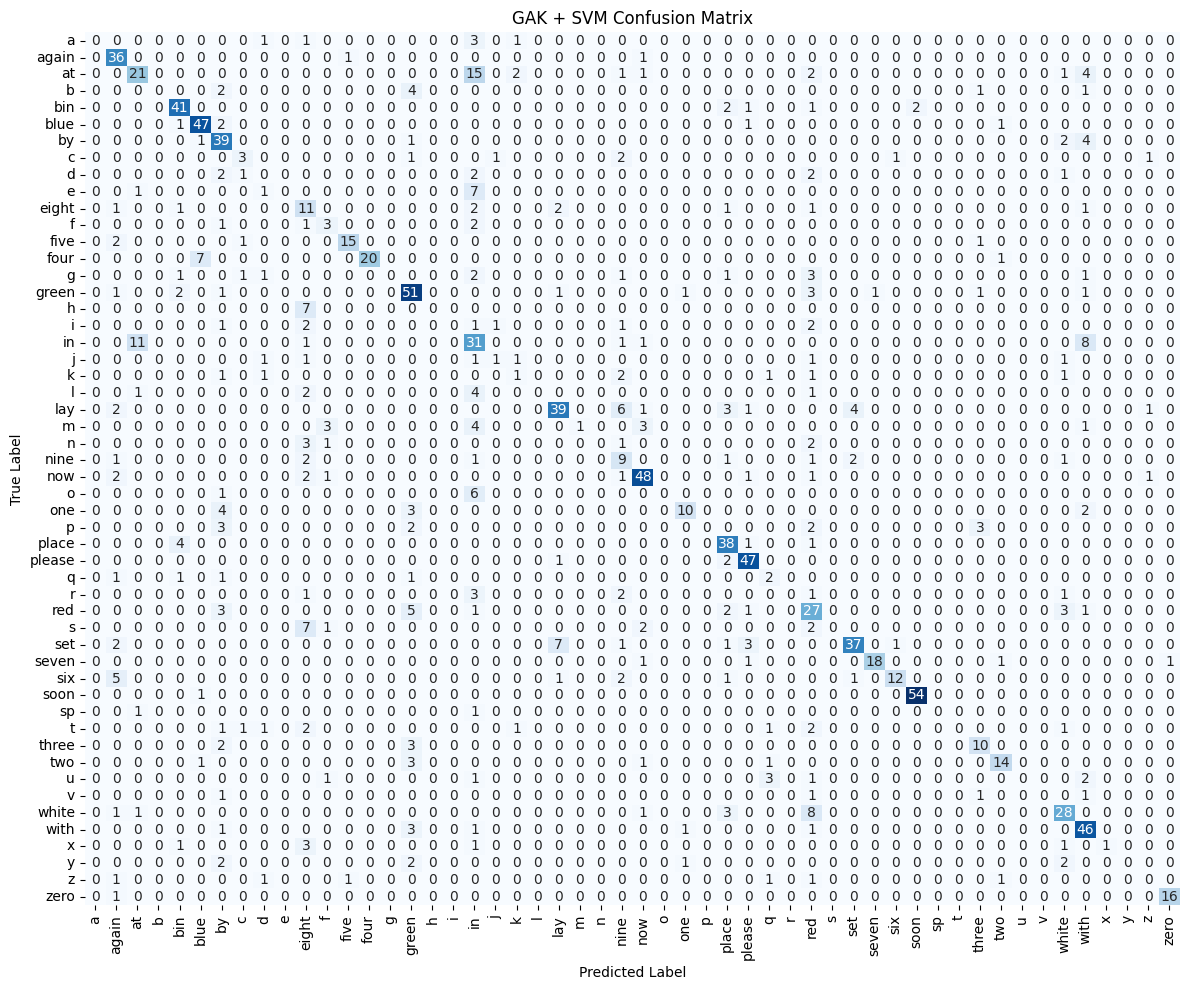

In [16]:
gak_results = train_evaluate_gak_svm(X_train, y_train, X_test, y_test, label_encoder, C=1.0, gamma="auto")

ai için promt olarak da şunu kullanabilirsin:

machine learning projemde yardımcı olmanı istiyorum projeyle alakalı detaylı bilgileri içeren bir kaynağı aşağıda paylaşacağım projenin ana amacı dudak hareketlerinden söylenen kelimeleri tahmin etmek veri seti için kaynağımız 5-6 saniyelik videolar her video içerisinde konuşmacı peş peşe birkaç kelime söylüyor ancak normal bir konuşma biçiminde değil, aralıklarla rastgele kelimeler söylüyor labeling için ise bezer isimli ikinci bir dosya içerisinde hangi aralıklarda hangi kelimeleri söylediği bulunuyor buna dayanarak bir proje hazırlayacağız şu an için proje kapsamını anlaman yeterli devamında proje üzerinde ilerleyeceğiz ayrıca veri setinin ve elde edilmiş featureların dosya yapısı da şu şekilde
+---data
|   +---alignments
|   |   \---s1
|   \---s1
\---features
    +---test
    \---train
data altındaki s1 içerisinde mpg uzantılı birkaç saniyelik ses dosyaları barındırıyor ve alignments altındaki kısımda .align uzantılı kullanılan kelimeleri belirten labellar bulunuyor örnek bir align dosyasının içeriği şu şekilde
0 23750 sil
23750 29500 bin
29500 34000 blue
34000 35500 at
35500 41000 f
41000 47250 two
47250 53000 now
53000 74500 sil

projenin içeriği ile ilgili kaynak da bu şekilde

Instructions: The main objective of this assignment is to build machine learning models that classify spoken words from silent lip movement videos.
Classification of Lip Movements on Videos
In this assignment, you will build machine learning models that classify spoken words from silent lip movement videos. Instead of training directly on raw video frames, which is computationally expensive, the assignment focuses on extracting facial landmark features from each frame, especially the mouth region. These landmarks will be converted into time-series representations of lip motion. To classify these lip movement sequences, you will experiment with different time-series classification approaches.

1. Dataset
In this assignment, you will use a public lipreading dataset for video-based word classification. The dataset consists of short video clips where each video contains a person pronouncing a sequence of words forming a short phrase. Unlike isolated word datasets, each video includes multiple words spoken continuously, which creates a more natural speaking scenario.
Each video is accompanied by an alignment file that specifies the exact time intervals for each spoken word. These alignment files indicate which word is being pronounced at a given time segment, allowing you to segment the video into word-level sequences if needed. Silent periods in the videos are explicitly labeled as “sil”, representing non-speaking intervals.
The dataset contains more than 50 different word classes, and the phrases vary across videos, meaning that the word order changes and does not follow a fixed pattern. This variability results in a non-homogeneous dataset, where class distributions and temporal structures may differ between samples. This makes the classification task more challenging and closer to real-world lipreading scenarios.
1.1. Feature Extraction on Dataset
Instead of using raw video frames, you will extract facial landmarks with MediaPipe Face Mesh to reduce complexity while preserving important lip motion information.
MediaPipe Face Mesh detects facial landmarks for each frame. In this assignment, you will use only the landmarks around the mouth and lip region. Each selected landmark is represented by its x and y coordinates, turning every video into a time-series representation of lip movement. This approach lowers dimensionality, focuses on mouth motion rather than full-frame appearance, and makes the data easier to use with sequence-based and time-series
classification models.
Each processed video should be saved as a .npz file containing the extracted lip landmark coordinates, normalized values, frame indices, the word label, and the original video path.
2. Approach
In this assignment, you will explore different methods for classifying spoken words from lip movement sequences. Each video will first be converted into a multivariate time-series representation by extracting lip landmarks from each frame using MediaPipe Face Mesh. Each time step represents the mouth shape at a specific frame, while the full sequence represents the temporal movement pattern of the lips during speech.
• Global Alignment Kernel (GAK) + SVM: GAK is a similarity measure designed for time-series data. It compares two lip movement sequences by softly aligning them over time, even if the speaking speed or word duration differs between videos. The resulting kernel matrix is then used with an SVM classifier to separate the word classes.
• Shapelets + MLP: Shapelets are short and informative subsequences that represent important local lip movement patterns. The Shapelet Transform converts each lip landmark sequence into a fixed-length feature vector by measuring its distance to selected shapelets. An MLP classifier is then trained on these transformed features to predict the spoken word.
• LSTM: An LSTM network directly processes the sequence of lip landmarks over time. By learning how mouth shapes change from frame to frame, the LSTM can capture temporal dependencies in lip motion and classify the spoken word.
• Suggested Method: You will also propose and implement one additional classification approach suitable for time-series data. For example, you may use a feature-based method that extracts statistical and temporal descriptors from lip landmark sequences, or another sequence classification model learned in class.
3. What should you do?
• Download the dataset from the provided Kaggle link.
• Extract lip landmark features from all videos using MediaPipe Face Mesh. Focus only on the mouth and lip region. Convert each video into a time-series representation of lip movements and save the extracted features as .npz files.
• Prepare the data by:
– Loading the lip landmark sequences,
– Applying normalization to reduce variations in scale and position,
– Padding or truncating sequences to a fixed length,
– Encoding the labels and splitting the dataset into training and test sets.
• Use the provided alignment files to segment videos into word-level sequences. You may ignore segments labeled as “sil” (silent).
• Implement the classification approaches using the extracted lip movement features:
– Global Alignment Kernel (GAK) combined with an SVM classifier
– Shapelet Transform followed by an MLP (PyTorch for MLP)
– LSTM-based sequence classification model (PyTorch for LSTM)
– Propose and implement one extra approach that uses a classification method covered in the course and is suitable for time-series data.
• Train and evaluate each model on the word classes. Perform a detailed ablation study for every approach. Experiment with different parameters and settings (such as kernel parameters, number and length of shapelets, MLP architecture, LSTM layers, or hidden sizes). Analyze how these changes affect performance instead of reporting only a single experiment per method.
• Present your results clearly, including:
– Accuracy scores,
– Confusion matrices,
– Tables or plots comparing different configurations.
• Compare all methods and discuss their performance, highlighting strengths, limitations, and common failure cases. In your report, evaluate the methods based on factors such as ease of implementation, classification performance, computational efficiency, and their suitability for lip movement–based time-series data.

başlangıcı yapılmış olan jupyter dosyasını da ekliyorum devam eden kısımda model eğitimleri ve analizleriyle ilerleyeceğiz eğitim süreciyle ilgili süreç boyunca hazırlamayı planladığım yapı bu aşamadan sonra her bir modelin hazırlanması eğitimi ve devamında metriklerin hesaplanıp görüntülenmesi en son kısımda bunlar bittikten sonra bütün modellerin karşılaştırmalı analizini yapmayı planladığım için buna yönelik bir yapıda ilerlemeni istiyorum

## Part 3: Analysis